/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:18: RuntimeWarning: divide by zero encountered in matmul
  Pi = F @ Phi @ np.conjugate(F.T)
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:18: RuntimeWarning: overflow encountered in matmul
  Pi = F @ Phi @ np.conjugate(F.T)
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:18: RuntimeWarning: invalid value encountered in matmul
  Pi = F @ Phi @ np.conjugate(F.T)
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:28: RuntimeWarning: divide by zero encountered in matmul
  0.5 * Pi @ Pi
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:28: RuntimeWarning: overflow encountered in matmul
  0.5 * Pi @ Pi
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:28: RuntimeWarning: invalid value encountered in matmul
  0.5 * Pi @ Pi
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000g

Layers = 3
Layers = 4
Layers = 5
Layers = 6
Layers = 3
Layers = 4
Layers = 5
Layers = 6
Layers = 3
Layers = 4
Layers = 5
Layers = 6


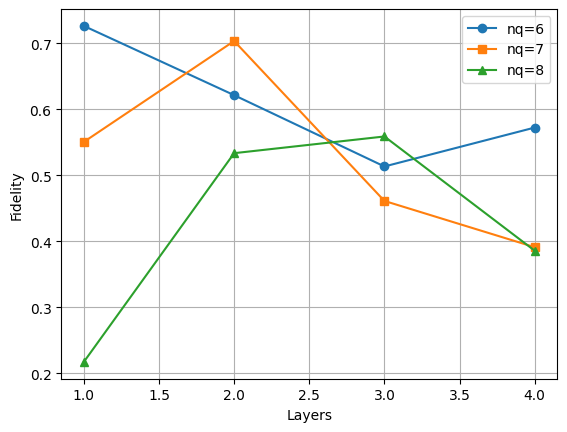

In [9]:
import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# ----------------------------
# Operators
# ----------------------------
def field_operators(nq, mu=1.0):
    Nphi = 2**nq
    delta_phi = np.sqrt(2*np.pi/(Nphi*mu))
    phi_vals = np.array([delta_phi*(i - (Nphi-1)/2) for i in range(Nphi)])
    
    Phi = np.diag(phi_vals)
    F = np.fft.fft(np.eye(Nphi))/np.sqrt(Nphi)
    Pi = F @ Phi @ np.conjugate(F.T)
    
    return Phi, Pi

# ----------------------------
# Hamiltonian
# ----------------------------
def local_hamiltonian(nq, m2, lam, f):
    Phi, Pi = field_operators(nq)
    return (
        0.5 * Pi @ Pi
        + 0.5 * m2 * Phi @ Phi
        + lam/24 * np.linalg.matrix_power(Phi, 4)
        + f * Phi
    )

# ----------------------------
# Ground state
# ----------------------------
def ground_state(H):
    vals, vecs = eigh(H)
    return vecs[:, 0]

# ----------------------------
# Circuit
# ----------------------------
def variational_circuit(nq, layers, params):
    qc = QuantumCircuit(nq)
    p = 0
    
    for l in range(layers):
        for q in range(nq):
            qc.ry(params[p], q)
            qc.rz(params[p+1], q)
            p += 2
        
        for q in range(0, nq-1, 2):
            qc.cz(q, q+1)
        for q in range(1, nq-1, 2):
            qc.cz(q, q+1)
    
    return qc

# ----------------------------
# Fidelity
# ----------------------------
def fidelity(params, nq, layers, target):
    qc = variational_circuit(nq, layers, params)
    psi = Statevector.from_instruction(qc).data
    return -np.abs(np.dot(np.conjugate(target), psi))**2

# ----------------------------
# Simulation
# ----------------------------
def run_simulation(nq=6, max_layers=6):
    m2 = -0.5
    lam = 1.0
    f = 0.1
    
    H = local_hamiltonian(nq, m2, lam, f)
    target = ground_state(H)
    
    fidelities = []
    
    for layers in range(3, 7):
        print(f"Layers = {layers}")
        
        n_params = layers * nq * 2
        x0 = np.random.uniform(0, 2*np.pi, n_params)
        
        res = minimize(
            fidelity,
            x0,
            args=(nq, layers, target),
            method='COBYLA',
            options={'maxiter': 150}
        )
        
        fid = -res.fun
        fidelities.append(fid)
      #  print("Fidelity:", fid)
    
    return fidelities

# ----------------------------
# Run
# ----------------------------
fids_6 = run_simulation(6)
fids_7 = run_simulation(7)
fids_8 = run_simulation(8)

layers = range(1, len(fids_6)+1)

plt.plot(layers, fids_6, 'o-', label='nq=6')
plt.plot(layers, fids_7, 's-', label='nq=7')
plt.plot(layers, fids_8, '^-', label='nq=8')

plt.xlabel("Layers")
plt.ylabel("Fidelity")
plt.legend()
plt.grid()
plt.show()

In [1]:
import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [2]:
def field_operators(nq, mu=1.0):
    Nphi = 2**nq
    
    # Discretized field values
    dphi = np.sqrt(2*np.pi/(Nphi*mu))
    phi = np.array([dphi*(i - (Nphi-1)/2) for i in range(Nphi)])

In [3]:
 # Φ operator (diagonal)
def build_operators(phi, mu):
    Phi = np.diag(phi)

    F = np.fft.fft(np.eye(Nphi)) / np.sqrt(Nphi)
    Pi = mu * F @ Phi @ F.conj().T

    return Phi, Pi

In [4]:
#Eq 24 
def phi_operator(nq, dphi):
    dim = 2**nq
    phi = np.zeros((dim, dim))
    
    for i in range(dim):
        val = 0
        for q in range(nq):
            bit = (i >> q) & 1
            val += (2**q) * (1 if bit == 0 else -1)
        phi[i, i] = -dphi * val / 2
    
    return phi

In [5]:
### Build local Hamiltonian (eq. 42)

#def build_H(Phi, Pi, mI2, lambdaI, fI):
#    H_loc = 0.5 * Pi @ Pi \
#        + 0.5 * mI2 * Phi @ Phi \
#        + (lambdaI / 24.0) * Phi @ Phi @ Phi @ Phi \
#       + fI * Phi
#    return H_loc

In [7]:
def local_hamiltonian(nq, m2, lam, f):
    Phi, Pi = field_operators(nq)
    H = 0.5 * Pi @ Pi\
        + 0.5 * m2 * Phi @ Phi\
        + lam/24 * np.linalg.matrix_power(Phi, 4)\
        + f * Phi
    return H

In [1]:
#Variatinal circuit
def ground_state(H):
    eigvals, eigvecs = eigh(H)
    return eigvecs[:, 0]

In [2]:
def variational_circuit(nq, layers, params):
    qc = QuantumCircuit(nq)
    idx = 0
    
    for l in range(layers):
        # single-qubit rotations
        for q in range(nq):
            qc.ry(params[idx], q)
            idx += 1
            qc.rz(params[idx], q)
            idx += 1
        
        # entanglement (alternating)
        for q in range(0, nq-1, 2):
            qc.cz(q, q+1)
        for q in range(1, nq-1, 2):
            qc.cz(q, q+1)
    
    return qc

In [3]:
def fidelity(params, nq, layers, target_state):
    qc = variational_circuit(nq, layers, params)
    psi = Statevector.from_instruction(qc).data
    
    return 1 - np.abs(np.vdot(target_state, psi))**2

In [4]:
def run_simulation(nq=6, max_layers=8):
    # Example parameters (same physics regime as paper)
    m2 = -0.5
    lam = 1.0
    f = 0.1
    
    H = local_hamiltonian(nq, m2, lam, f)
    target = ground_state(H)
    
    fidelities = []
    
    for layers in range(1, max_layers+1):
        print(f"Running layers = {layers}")
        
        n_params = layers * nq * 2
        
        x0 = np.random.uniform(0, 2*np.pi, n_params)
        
        res = minimize(
            fidelity,
            x0,
            args=(nq, layers, target),
            method='COBYLA',
            options={'maxiter': 200}
        )
        
        fid = -res.fun
        fidelities.append(fid)
        
        print(f"Fidelity = {fid:.6f}")
    
    return fidelities

In [8]:
import matplotlib.pyplot as plt

fids_6 = run_simulation(nq=6)
fids_7 = run_simulation(nq=7)
fids_8 = run_simulation(nq=8)

layers = range(1, len(fids_6)+1)

plt.plot(layers, fids_6, 'o-', label='nq=6')
plt.plot(layers, fids_7, 's-', label='nq=7')
plt.plot(layers, fids_8, '^-', label='nq=8')

plt.xlabel("Number of Entanglement Layers")
plt.ylabel("Fidelity")
plt.title("Reproduction of Fig. 3")
plt.legend()
plt.grid()
plt.show()

NameError: name 'field_operators' is not defined

In [28]:
def optimize(nq, layers, target_state):
    n_params = layers * nq * 2
    init = np.random.uniform(0, 2*np.pi, n_params)
    
    res = minimize(
        fidelity,
        init,
        args=(nq, layers, target_state),
        method='COBYLA',
        options={'maxiter': 200}
    )
    
    return 1 - res.fun  # return fidelity

In [6]:
#Eq 42

def local_hamiltonian(nq, m2, lam, f, dphi):
    phi = phi_operator(nq, dphi)
    pi = pi_operator(nq)

    H = (
        0.5 * (pi @ pi)
        + 0.5 * m2 * (phi @ phi)
        + (lam / 24) * (phi @ phi @ phi @ phi)
        + f * phi
    )
    return H

In [9]:
import matplotlib.pyplot as plt

nq_list = [6]   # extend to [6,7,8]
layers_list = range(1, 9)

# parameters (example from paper)
m2 = 1.0
lam = 0.0
f = 0.0
delta_phi = 0.5

results = {}

In [10]:
for nq in nq_list:
    H = local_hamiltonian(nq, m2, lam, f, delta_phi)
    target = ground_state(H)
    
    fidelities = []
    
    for L in layers_list:
        F = optimize(nq, L, target)
        fidelities.append(F)
        print(f"nq={nq}, layers={L}, F={F:.4f}")
    
    results[nq] = fidelities


NameError: name 'pi_operator' is not defined

In [50]:
# Plot
for nq in nq_list:
    plt.plot(layers_list, results[nq], label=f"nq={nq}")

plt.xlabel("Entanglement Layers")
plt.ylabel("Fidelity")
plt.title("Reproduction of Figure 3")
plt.legend()
plt.show()

KeyError: 6

In [29]:
####Build operators Phi and Pi

def build_operators(phi, mu):
    Phi = np.diag(phi)

    F = np.fft.fft(np.eye(Nphi)) / np.sqrt(Nphi)
    Pi = mu * F @ Phi @ F.conj().T

    return Phi, Pi

In [30]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def variational_circuit(nq, layers, params):
    qc = QuantumCircuit(nq)
    p = 0
    
    for l in range(layers):
        # Single-qubit rotations
        for q in range(nq):
            qc.ry(params[p], q)
            p += 1
            qc.rz(params[p], q)
            p += 1
        
        # Entangling layer
        for q in range(0, nq-1, 2):
            qc.cz(q, q+1)
        for q in range(1, nq-1, 2):
            qc.cz(q, q+1)
    
    return qc

In [31]:
### Build local Hamiltonian (eq. 42)

def build_H(Phi, Pi, mI2, lambdaI, fI):
    H_loc = 0.5 * Pi @ Pi \
        + 0.5 * mI2 * Phi @ Phi \
        + (lambdaI / 24.0) * Phi @ Phi @ Phi @ Phi \
        + fI * Phi
    return H_loc

    eigvals, eigvecs = np.linalg.eigh(H_loc)
    psi_target = eigvecs[:, 0]  # ground state


In [32]:
def fidelity(params, nq, layers, psi_target):
    qc = variational_circuit(nq, layers, params)
    psi = Statevector.from_instruction(qc).data
    return -np.abs(np.vdot(psi_target, psi))**2

In [16]:
from scipy.optimize import minimize

layers_list = list(range(3, 6))

fidelity_n6 = []


In [17]:
for L in layers_list:
    num_params = 2 * nq * L  

    init = np.random.uniform(0, 2*np.pi, num_params)

    res = minimize(fidelity, init,
                   args=(nq, L, psi_target),
                   method='COBYLA')

    F = -res.fun
   # fidelity_n6.append(F)

NameError: name 'psi_target' is not defined

In [18]:
plt.figure(figsize=(6,4))

plt.plot(layers, fidelity_n6, label='nq=6')
plt.plot(layers, fidelity_n7, label='nq=7')
plt.plot(layers, fidelity_n8, label='nq=8')
plt.xlabel("Entanglement layers")
plt.ylabel("Fidelity")
plt.legend()

NameError: name 'layers' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
#For Fig 3 6 qubits 

In [16]:
cases = [
    {"label": "Gaussian", "m2": 1.0,  "lam": 0.0,  "f": 0.0, "marker": "s"},
    {"label": "Anharmonic", "m2": 1.0, "lam": 100.0, "f": 0.0, "marker": "^"},
    {"label": "Neg mass small f", "m2": -1.0, "lam": 1.0, "f": 0.01, "marker": "D"},
    {"label": "Neg mass large f", "m2": -1.0, "lam": 1.0, "f": 1.0, "marker": "*"},
]

In [17]:
def run_case(nq, m2, lam, f, layer_range):
    H = local_hamiltonian(nq, m2, lam, f)
    target = ground_state(H)

    fids = []

    for layers in layer_range:
        n_params = layers * nq * 2
        x0 = np.random.uniform(0, 2*np.pi, n_params)

        res = minimize(
            fidelity,
            x0,
            args=(nq, layers, target),
            method='COBYLA',
            options={'maxiter': 150}
        )

        fids.append(-res.fun)

    return fids

In [20]:
layer_range = range(3, 7)

results = {}

for case in cases:
    print("Running:", case["label"])
    results[case["label"]] = run_case(
        nq=6,
        m2=case["m2"],
        lam=case["lam"],
        f=case["f"],
        layer_range=layer_range
    )

Running: Gaussian


/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:18: RuntimeWarning: divide by zero encountered in matmul
  Pi = F @ Phi @ np.conjugate(F.T)
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:18: RuntimeWarning: overflow encountered in matmul
  Pi = F @ Phi @ np.conjugate(F.T)
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:18: RuntimeWarning: invalid value encountered in matmul
  Pi = F @ Phi @ np.conjugate(F.T)
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:28: RuntimeWarning: divide by zero encountered in matmul
  0.5 * Pi @ Pi
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:28: RuntimeWarning: overflow encountered in matmul
  0.5 * Pi @ Pi
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000gn/T/ipykernel_87237/3073196325.py:28: RuntimeWarning: invalid value encountered in matmul
  0.5 * Pi @ Pi
/var/folders/g6/7wnpvdrx3pq6vgv_ykqncp7w0000g

Running: Anharmonic
Running: Neg mass small f
Running: Neg mass large f


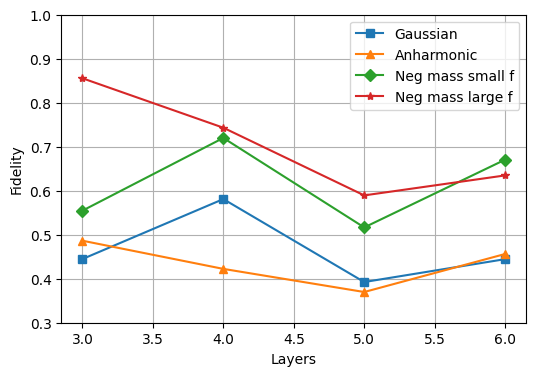

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(6,4))

# Main plot
for case in cases:
    ax.plot(
        list(layer_range),
        results[case["label"]],
        marker=case["marker"],
        label=case["label"]
    )

ax.set_ylabel("Fidelity")
ax.set_xlabel("Layers")
ax.set_ylim(0.3, 1.0002)
ax.legend()
ax.grid()

# 🔍 Inset (zoom)
#axins = inset_axes(ax, width="40%", height="40%", loc="lower right")

#for case in cases:
#    axins.plot(
#        list(layer_range),
 #       results[case["label"]],
#        marker=case["marker"]
#    )

#axins.set_ylim(0.9998, 1.00005)
#axins.set_xlim(4.5, 6.2)
#axins.grid()

plt.show()